In [1]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join("../")))

import numpy as np
import matplotlib.pyplot as plt
import time 
from src.parameters import Parameters
from src.acquisition import Acquisition
from src.forward import forward
from src.layers import create_layers, update_from_arrays
from src.plot.plot_tools import plot_1d_profile, plot_layered_config

r = compute_reflectivity(h,vp,rho,omegas,p,free_surface,zr,zs)

Wrapper for ``compute_reflectivity``.

Parameters
----------
h : input rank-1 array('d') with bounds (nlay)
vp : input rank-1 array('d') with bounds (nlay)
rho : input rank-1 array('d') with bounds (nlay)
omegas : input rank-1 array('G') with bounds (nw)
p : input rank-1 array('d') with bounds (nkq)
free_surface : input int
zr : input float
zs : input float

Returns
-------
r : rank-2 array('G') with bounds (nw,nkq)



In [9]:
vps = np.array([1500., 2800., 3800., 2300., 6500.])
vp_ref = np.array([vps[3], vps[4]])
hs = np.array([150.0, 250.0, 380.0, 460.0, 600.0])
rhos = np.array([2000.0, 2000.0, 2000.0, 2000.0, 2000.0])
layers = create_layers(hs, vps, rhos)
print(layers)

# configuration
fs = True
total_time = 2.5    # seconds
f0 = 6.0            # Ricker central frequency (Hz)
f_max = 8.0 * f0    # practical Ricker cutoff
# Nyquist frequency for f_max
dt = 1/(2.*f_max)
nfft = 2**int(np.ceil(np.log2(total_time/dt)))
nfft *= 2 # zero-padding to ensure late wrap-around
nt = int(total_time / dt) + 1

param = Parameters(total_time=total_time, nt=nt, f0=f0, nfft=nfft, epsilon=1.0)


sources = [(30., 76.)]
Nr = 81 # 
x_receivers = np.linspace(50.0, 2500.0, Nr)
receivers = [(x, 76.0) for x in x_receivers]
#print("receivers x-positions:", x_receivers)
dx_recv = x_receivers[1] - x_receivers[0]
acq = Acquisition(sources, receivers)
nquad = 1024

Parameters.__repr__(param)
print(x_receivers)

[Layer(h=150.0, vp=1500.0, rho=2000.0), Layer(h=250.0, vp=2800.0, rho=2000.0), Layer(h=380.0, vp=3800.0, rho=2000.0), Layer(h=460.0, vp=2300.0, rho=2000.0), Layer(h=600.0, vp=6500.0, rho=2000.0)]
[  50.      80.625  111.25   141.875  172.5    203.125  233.75   264.375
  295.     325.625  356.25   386.875  417.5    448.125  478.75   509.375
  540.     570.625  601.25   631.875  662.5    693.125  723.75   754.375
  785.     815.625  846.25   876.875  907.5    938.125  968.75   999.375
 1030.    1060.625 1091.25  1121.875 1152.5   1183.125 1213.75  1244.375
 1275.    1305.625 1336.25  1366.875 1397.5   1428.125 1458.75  1489.375
 1520.    1550.625 1581.25  1611.875 1642.5   1673.125 1703.75  1734.375
 1765.    1795.625 1826.25  1856.875 1887.5   1918.125 1948.75  1979.375
 2010.    2040.625 2071.25  2101.875 2132.5   2163.125 2193.75  2224.375
 2255.    2285.625 2316.25  2346.875 2377.5   2408.125 2438.75  2469.375
 2500.   ]


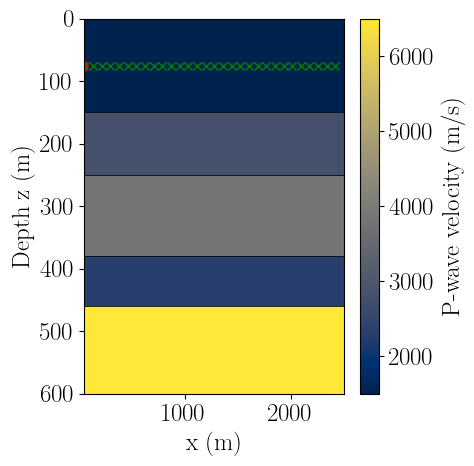

In [3]:
xmin, xmax = 0, np.max(x_receivers)
x = np.linspace(xmin, xmax, 100)
#plot_1d_profile(layers=layers, param='vp')
plot_layered_config(layers, xrecvs=x_receivers, xs=sources, param='vp', cmap='cividis')

In [10]:
# generate observations
d_obs = forward(layers, acq, param, nq_prop=nquad, free_surface=fs)
nobs = d_obs.shape[1]
Nt = len(param.time)
std_noise = 0.01
ampli = np.max(np.abs(d_obs[0, :, :]))
print('max trace ampli = ', ampli)
d_obs_noise = np.zeros(d_obs.shape)
noise = np.random.normal(loc=0, scale=std_noise, size=Nt)
for i in range(Nr):
    d_obs_noise[0, i, :] = d_obs[0, i, :] + noise

max trace ampli =  0.28797458469653203


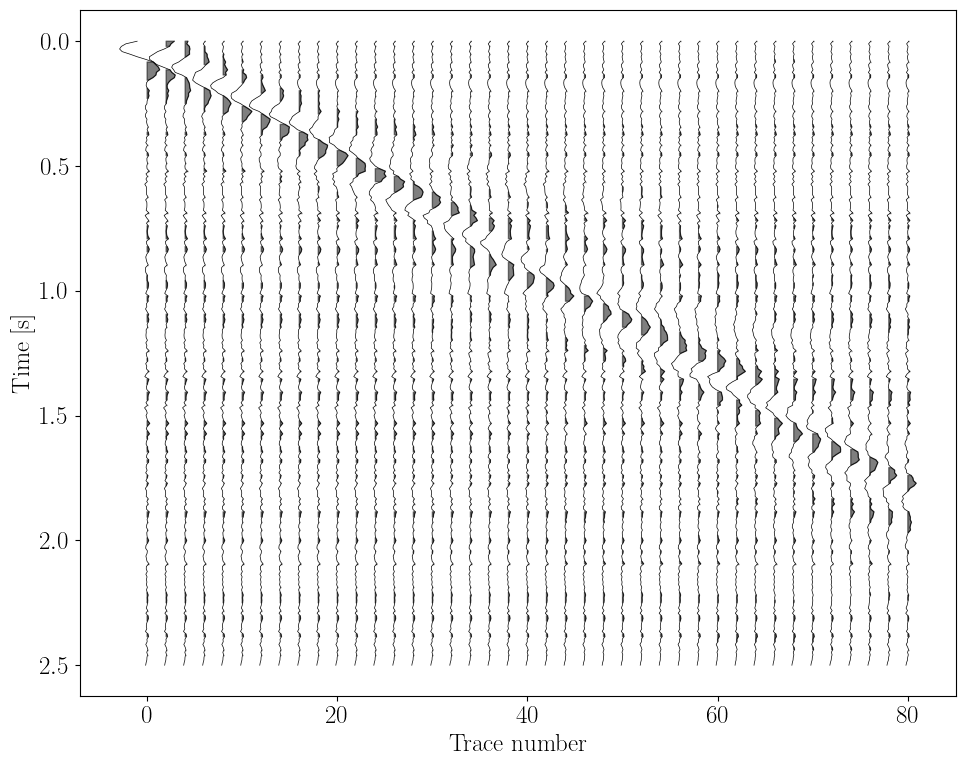

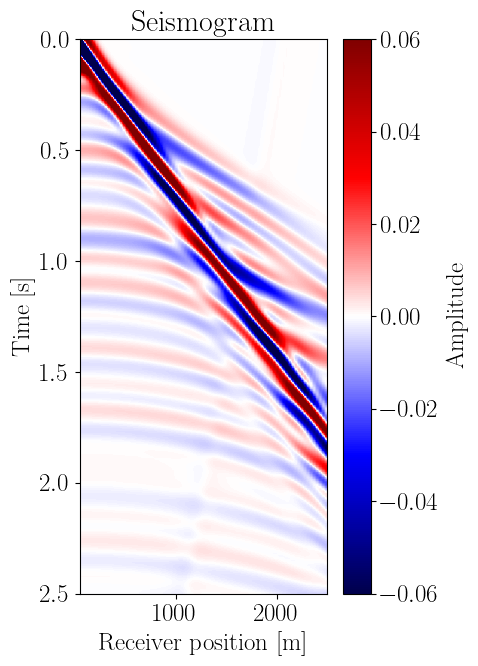

In [11]:
from src.plot.plot_tools import plot_wiggle_traces, plot_seismogram
plot_wiggle_traces(d_obs_noise[0, :, :], xrecvs=x_receivers, time=param.time, trace_step=2, scale=10.)
plot_seismogram(d_obs.T, x_receivers, param.time, vmin=-0.06, vmax=0.06, ncolors=256, figsize=(5,7))

In [7]:
def l2_misfit(dcal, dobs, std_noise):
    nobs = float(dobs.shape[1])
    return 0.5 * param.dt * np.sum((dcal - dobs)**2) / (nobs*std_noise**2)

def l2_misfit_nobs(dobs, dcal, ind_obs=[0, 3, 5]):
    nobs = len(ind_obs)
    err = 0.
    for i in range(len(ind_obs)):
        dob = dobs[0, ind_obs[i], :]
        dca = dcal[0, ind_obs[i], :]
        err += np.sum((dca - dob)**2)
    err *= 0.5 * param.dt / (nobs)
    return err

print(param.dt)
print(nobs)
L2_Err = l2_misfit(d_obs_noise, d_obs, std_noise=0.01)
print("misfit total = ", L2_Err)

L2_Err0 = l2_misfit_nobs(d_obs_noise, d_obs, ind_obs=[0])
print("misfit 0 = ", L2_Err0)
L2_Err2 = l2_misfit_nobs(d_obs_noise, d_obs, ind_obs=[12, 24])
print("misfit 2 = ", L2_Err2)
L2_Err3 = l2_misfit_nobs(d_obs_noise, d_obs, ind_obs=[0, 15, 30])
print("misfit 3 = ", L2_Err3)
L2_Err5 = l2_misfit_nobs(d_obs_noise, d_obs, ind_obs=[6, 12, 18, 24, 30])
print("misfit 5 = ", L2_Err5)
L2_Err10 = l2_misfit_nobs(d_obs_noise, d_obs, ind_obs=[i for i in range(11)])
print("misfit 10 = ", L2_Err10)

0.010416666666666666
31
misfit total =  1.3668849992925625
misfit 0 =  0.0001366884999292563
misfit 2 =  0.00013668849992925627
misfit 3 =  0.00013668849992925627
misfit 5 =  0.00013668849992925627
misfit 10 =  0.00013668849992925627


In [8]:
vps[2] = 2800.
vps[3] = 3500.
layers_test = update_from_arrays(layers, vps=vps)
d_cal = forward(layers_test, acq, param, nq_prop=nquad, free_surface=fs)

misfit =  2.715401447446669e-05
misfit noisy =  1.6634860691925557


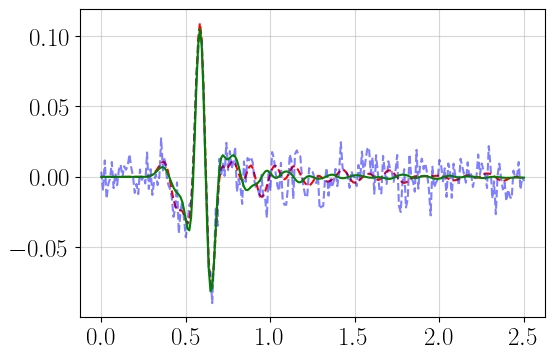

In [8]:
irecv = 10
plt.figure(figsize=(6,4))
plt.plot(param.time, d_obs[0, irecv, :], 'r--', label='observed - reference')
plt.plot(param.time, d_obs_noise[0, irecv, :], 'b--', alpha = 0.5, label='observed - noisy')
plt.plot(param.time, d_cal[0, irecv, :], 'g-', alpha = 1., label='observed - noisy')
#plt.legend()
plt.grid()

L2_Err_noise = l2_misfit(d_obs_noise, d_cal, std_noise=std_noise) 
L2_Err = l2_misfit_nobs(d_obs, d_cal, ind_obs=[irecv]) 
print("misfit = ", L2_Err)
print("misfit noisy = ", L2_Err_noise)

In [9]:
vp_min, vp_max, npts = 1500, 5000, 50
vp_min2, vp_max2 = 1500, 5000

#vp0, vp1, vp2 = 1900., 2800., 4200.

x_vals = np.linspace(vp_min, vp_max, npts)
y_vals = np.linspace(vp_min2, vp_max2, npts)
xgrid, ygrid = np.meshgrid(x_vals, y_vals, indexing='ij')
COST = np.empty_like(xgrid)
COST1 = np.empty_like(xgrid)
COST2 = np.empty_like(xgrid)
COST4 = np.empty_like(xgrid)
COST5 = np.empty_like(xgrid)
COST5_bis = np.empty_like(xgrid)
COST10 = np.empty_like(xgrid)

start_time = time.time()
for i in range(npts):
    for j in range(npts):
        point = np.array([xgrid[i, j], ygrid[i, j]])
        vps[2], vps[3] = point[0], point[1]
        layers = update_from_arrays(layers, vps=vps)
        dcal = forward(layers, acq, param, free_surface=fs, nq_prop=nquad)
        COST[i,j] = l2_misfit(dcal, d_obs, std_noise=1.)
        COST1[i,j] = l2_misfit_nobs(dcal, d_obs, ind_obs=[6])
        COST2[i,j] = l2_misfit_nobs(dcal, d_obs, ind_obs=[12, 24])
        COST4[i,j] = l2_misfit_nobs(dcal, d_obs, ind_obs=[9, 15, 21, 27])
        COST5[i,j] = l2_misfit_nobs(dcal, d_obs, ind_obs=[0, 6, 12, 18, 24, 30])
        COST5_bis[i,j] = l2_misfit_nobs(dcal, d_obs, ind_obs=[15, 16, 17, 18, 19])
        COST10[i,j] = l2_misfit_nobs(dcal, d_obs, ind_obs=[0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30])

elapsed_time = time.time() - start_time
print(f"generated misfit map in {elapsed_time:.3f} seconds.")
print(f"time per forward is {elapsed_time/(npts*npts):.3f} seconds.")

generated misfit map in 524.733 seconds.
time per forward is 0.210 seconds.


In [10]:
def create_plot(X, Y, Z):
    plt.figure(figsize=(8, 5))
    maxZ = np.max(Z)
    contour_lines = plt.contour(X, Y, Z/maxZ, levels=16, 
                                    colors="black", linewidths=1., linestyles="dotted")
    plt.clabel(contour_lines, inline=True, fontsize=6, fmt="%.2f")  # Add isovalue labels
    plt.contourf(X, Y, Z/maxZ, levels=16, cmap="viridis_r")
    plt.colorbar(label="$L^2$ misfit", aspect=50)
    plt.scatter(vp_ref[0], vp_ref[1], s=115, c="red", marker='*', alpha=1, edgecolors='k')
    plt.xlabel(r'$V_{P,2}$ [m/s]')
    plt.ylabel(r'$V_{P,3}$ [m/s]')
    #plt.xlim([1000, 2500])
    #plt.ylim([1000, 4000])
    plt.xlim([vp_min, vp_max])
    plt.ylim([vp_min2, vp_max2])
    plt.tight_layout()

1 receiver at x =  540.0 m
2 receivers at x = [ 1030.0 , 2010.0 ] m
4 receivers at x = [ 785.0 , 1275.0 , 1765.0 , 2255.0 ] m
5 receivers at x = [ 50.0 , 540.0 , 1030.0 , 1520.0 , 2010.0 ] m
10 equally spaced receivers
30 equally spaced receivers


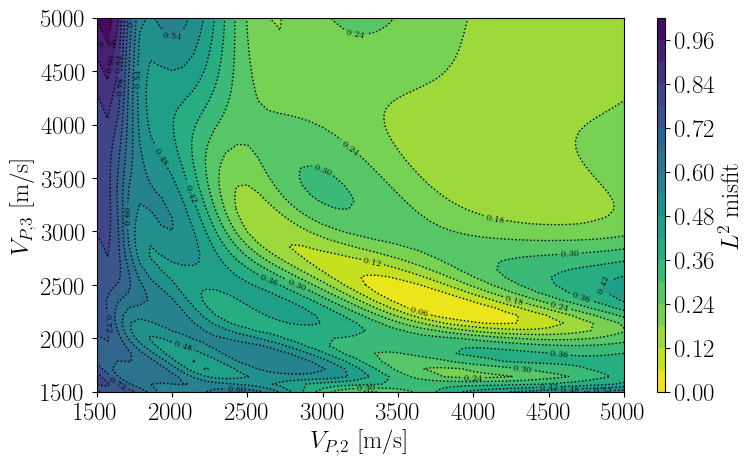

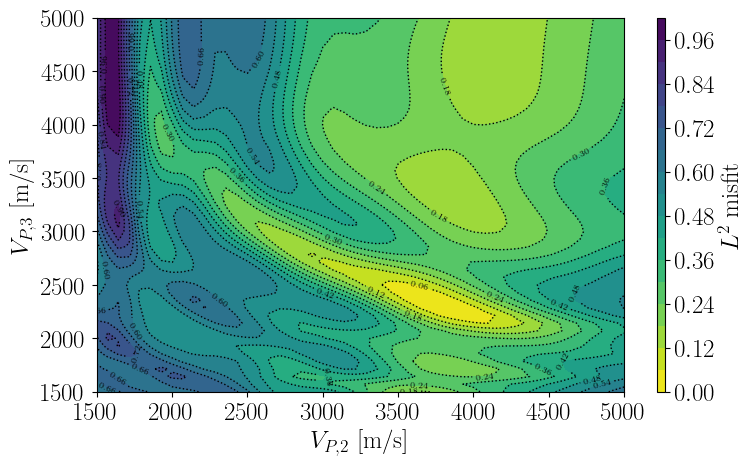

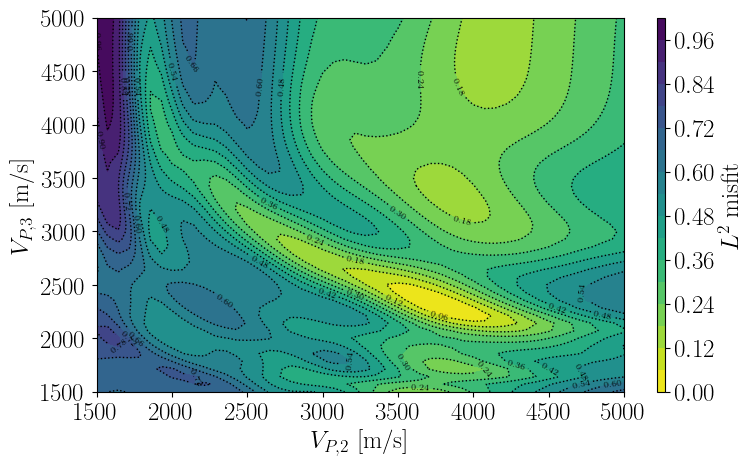

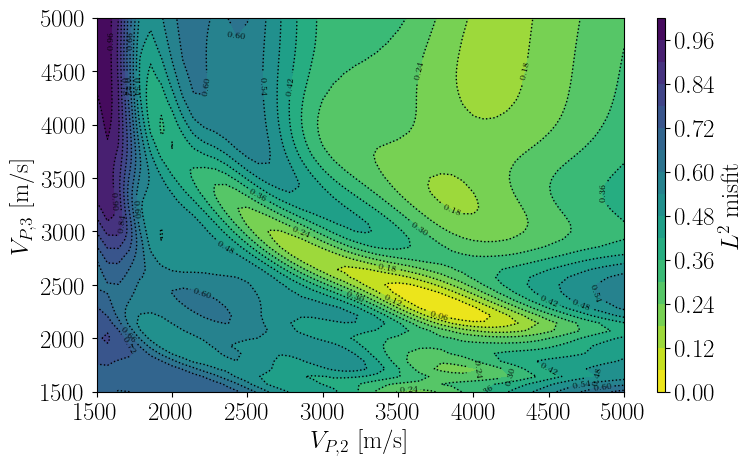

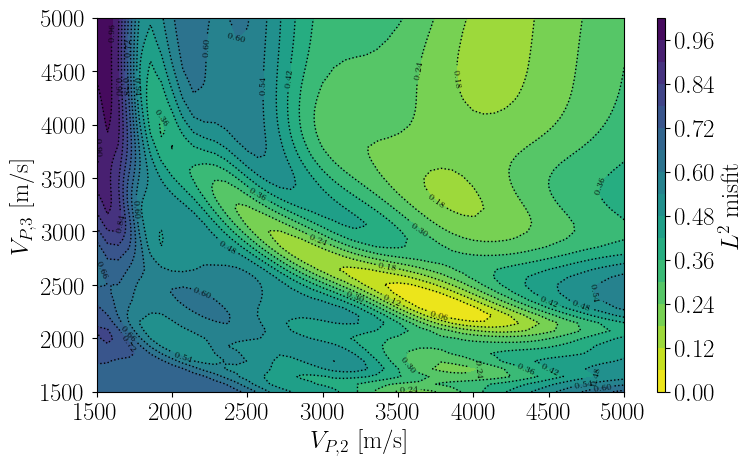

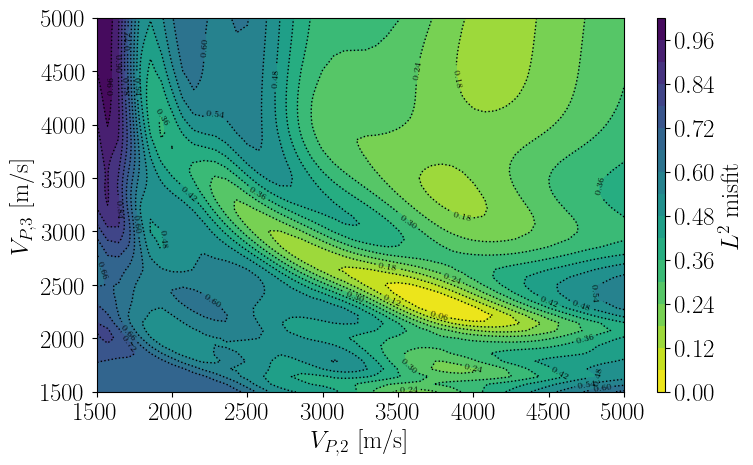

In [11]:
print("1 receiver at x = ", x_receivers[6], "m")
create_plot(xgrid, ygrid, COST1)
#plt.savefig('L2_cost_1_receiver.png', dpi=300)
print("2 receivers at x = [", x_receivers[12], ",", x_receivers[24], "] m")
create_plot(xgrid, ygrid, COST2)
#plt.savefig('L2_cost_2_receivers.png', dpi=300)
print("4 receivers at x = [", x_receivers[9], ",", x_receivers[15], ",", x_receivers[21], ",", x_receivers[27], "] m")
create_plot(xgrid, ygrid, COST4)
#plt.savefig('L2_cost_4_receivers.png', dpi=300)
print("5 receivers at x = [", x_receivers[0], ",", x_receivers[6], ",", x_receivers[12], ",", x_receivers[18], ",", x_receivers[24], "] m")
create_plot(xgrid, ygrid, COST5)
#plt.savefig('L2_cost_5_receivers.png', dpi=300)
print("10 equally spaced receivers")
create_plot(xgrid, ygrid, COST10)
#plt.savefig('L2_cost_10_receivers.png', dpi=300)
print("30 equally spaced receivers")
create_plot(xgrid, ygrid, COST)
#plt.savefig('L2_cost_30_receivers.png', dpi=300)

In [12]:
def gaussian_prior_2d(xgrid, ygrid, mean, std):
    mean = np.asarray(mean)
    std = np.asarray(std)
    # Normalization constant
    norm = 1.0 / (2 * np.pi * std[0] * std[1])
    # Compute exponent
    dx = (xgrid - mean[0]) / std[0]
    dy = (ygrid - mean[1]) / std[1]
    exponent = -0.5 * (dx**2 + dy**2)
    return np.exp(exponent)

vp_mean = [3000., 3000.]
std = [1000, 1000]   # sqrt of diagonal cov
# Compute prior
prior = gaussian_prior_2d(xgrid, ygrid, vp_mean, std)
# Compute posterior
likelihood = np.exp(-(COST/np.max(COST)))
print("max", np.max(COST))
posterior = prior * likelihood

max 8.577075129806007e-05


NameError: name 'vp2' is not defined

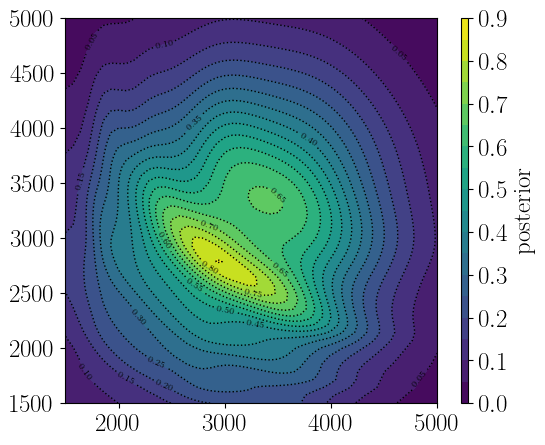

In [13]:
plt.figure(figsize=(6, 5))
contour_lines = plt.contour(xgrid, ygrid, posterior, levels=16, 
                                    colors="black", linewidths=1., linestyles="dotted")
plt.clabel(contour_lines, inline=True, fontsize=6, fmt="%.2f")  # Add isovalue labels
plt.contourf(xgrid, ygrid, posterior, levels=16, cmap="viridis")
plt.colorbar(label="posterior", aspect=50)
plt.scatter(vp2, vp3, s=115, c="red", marker='*', alpha=1, edgecolors='k')
plt.xlim([vp_min, vp_max])
plt.ylim([vp_min2, vp_max2])
plt.tight_layout()
plt.show()